# Code for doing the different clustering methods, as well as data preprocessing

In this file we run the different methods

### DMACN - Deep Multi-kernel Auto-encoder Clustering Network
First load the data

In [ ]:
# Example data from article about DMACN - PTSD dataset

from scipy.io import loadmat
import torch

# Load the data
PTSD = loadmat("C:\\Users\\oddar\\Downloads\\PTSD_connectivity.mat")
# PTSD is a dataset containing 87 samples (subjects) with 340 features (as vectorized functional connectivity matrices)
# The expected number of clusters are 3

# Define the functional connectivity matrix (example)
Functional_connectivity_matrix = PTSD["connectivities"]  # Example matrix

PTSD_tensor = torch.from_numpy(Functional_connectivity_matrix).float()

# Dummy data
X = PTSD_tensor  # [N,d] float tensor
print("Data shape:", X.shape)

In [ ]:
# Example data from article about DMACN - AD dataset

from scipy.io import loadmat
import torch

# Load the data
AD = loadmat("Input Data\AD_connectivity.mat")
# AD is a dataset containing 96 samples (subjects) with 888 features (as vectorized functional connectivity matrices)
# The expected number of clusters are 4

# Define the functional connectivity matrix (example)
Functional_connectivity_matrix = AD["connectivities"]  # Example matrix

AD_tensor = torch.from_numpy(Functional_connectivity_matrix).float()

# Dummy data
X = AD_tensor  # [N,d] float tensor
print("Data shape:", X.shape)

In [ ]:
# Loading the data with 29 features (for 29x29 data)
# subject_features.npz contains the vectorized upper triangle of the 29x29 FC matrices, resulting in 50 features per sample.
from scipy.io import loadmat
import torch
from data_loader import load_workable_fc


filepath = "Prosjektoppgave-Odd-Arne-og-Mats-main\\subject_features.npz" # All subjects, 50 features

Functional_connectivity_matrix = load_workable_fc(filepath)

Functional_connectivity_matrix.to_csv("subject_features_clean.csv", index=True)

print(Functional_connectivity_matrix.shape)

X = torch.from_numpy(Functional_connectivity_matrix.values).float()


In [ ]:
# Loading the data with all 200 features (for 200x200 data)
# 200_schaefer_vectorized_fc.mat contains the vectorized upper triangle of the 200x200 FC matrices, resulting in 19900 features per sample.

from scipy.io import loadmat
import torch
import numpy as np

FC_test_mat = loadmat("Input Data\\200_schaefer_vectorized_fc.mat")
# FC_test_mat = loadmat("C:\\Mats og Odd Arne\\Prosjektoppgave\\sch407\\YA\\200_schaefer_vectorized_fc.mat")  # Load the .mat file

FC_test_array = FC_test_mat["200_vectorized_fc"]  # Example matrix
# np.fill_diagonal(FC_test_array, 1.0)  # Set diagonal to zero

print(FC_test_array[0:5].shape)  # Print the first 5 rows to verify

X = torch.from_numpy(FC_test_array).float()  # Example matrix

# Check if any values are abs(X) > 1.0
if torch.any(torch.abs(X) > 1.0):
    print("Warning: Some values in X have absolute value greater than 1.0, which may cause numerical issues in the polynomial kernel.")

In [1]:
#  Loading the data with all 200 features (for 200x200 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "Input Data\FC1.mat"
fc_mat = loadmat(filepath)
fc_mat = fc_mat['FC1']  # Extract the FC1 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (200, 200, N_subjects)

fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)
fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 200, 200)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 200, 200)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 200, 200)

# Expected shape is (Batch size, channels, height, width)

(200, 200, 72)
(72, 1, 200, 200)
Data shape: torch.Size([72, 1, 200, 200])


In [ ]:
# Loading the data with all 672 features (for 487x672 data) - ADHD dataset

from data_loader import load_static_functional_connectiviies

ADHD = load_static_functional_connectiviies("Input Data\ADHD_connectivity.mat")

Define the autoencoder specs

In [ ]:
kernel_specs = [
    {"kind": "rbf", "t0": 0.01},
    {"kind": "rbf", "t0": 0.05},
    {"kind": "rbf", "t0": 0.1},
    {"kind": "rbf", "t0": 1},
    {"kind": "rbf", "t0": 10},
    {"kind": "rbf", "t0": 50},
    {"kind": "rbf", "t0": 100},
    {"kind": "poly", "a": 0, "b": 2},
    {"kind": "poly", "a": 0, "b": 4},
    {"kind": "poly", "a": 1, "b": 2},
    {"kind": "poly", "a": 1, "b": 4}
]  # h = 3

In [ ]:
# Config for 340x340 data PTSD
from DMACN import DMACN, DMACNConfig


cfg = DMACNConfig(
    name="PTSD_340x340",
    C=3,  # number of clusters
    dims_enc=[340, 285, 240, 202, 170],   # mid = 2 encoder Linear layers = L/2
    dims_dec=[170, 202, 240, 285, 340],
    kernel_specs=kernel_specs,
    m_fuzz=1.08,
    lam1=0.5,
    lam2=0.5,
    lr=1e-3,
    epochs=200,
    mk_max_iters=20,
    mk_eps_stop=1e-5,
    renormalize_omega_sum1=True,
    mid_only_first=True,
    mid_only_last=True,
)

In [ ]:
# Config for 888x888 data AD
from DMACN import DMACN, DMACNConfig


cfg = DMACNConfig(
    name="AD_888x888",
    C=4,  # number of clusters
    dims_enc=[888, 747, 628, 528, 444],   # mid = 2 encoder Linear layers = L/2
    dims_dec=[444, 528, 628, 747, 888],
    kernel_specs=kernel_specs,
    m_fuzz=1.08,
    lam1=1e-2,
    lam2=0.5,
    lr=1e-3,
    epochs=500,
    mk_max_iters=20,
    mk_eps_stop=1e-5,
    renormalize_omega_sum1=True,
    mid_only_first=True,
    mid_only_last=True,
)

In [ ]:
# Config for 29x29 data
from DMACN import DMACN, DMACNConfig


# Config for 29x29 data
cfg = DMACNConfig(
    name = "DMACN_29x29",
    C=3,  # number of clusters
    dims_enc=[29, 25, 22, 19, 17],   # N / 2^(i/l). l=number of layers, N=number of features 
    dims_dec=[17, 19, 22, 25, 29],
    kernel_specs=kernel_specs,
    m_fuzz=1.08,
    lam1=0.5,
    lam2=0.5,
    lr=1e-3,
    epochs=500,
    mk_max_iters=20,
    mk_eps_stop=1e-5,
    renormalize_omega_sum1=True,
    mid_only_first=True,
    mid_only_last=True,
)

In [ ]:
# Config for 19900x19900 data
from DMACN import DMACN, DMACNConfig

# Config for 19900x19900 data
cfg = DMACNConfig(
    C=3,  # number of clusters
    dims_enc=[19900, 15795, 12536, 9950],   # N / 2^(i/l). l=number of layers, N=number of features 
    dims_dec=[9950, 12536, 15795, 19900],
    kernel_specs=kernel_specs,
    m_fuzz=1.08,
    lam1=100,
    lam2=0.5,
    lr=1e-3,
    epochs=200,
    mk_max_iters=200,
    mk_eps_stop=1e-5,
    renormalize_omega_sum1=True,
    mid_only_first=True,
    mid_only_last=True,
)

Config for CAE

In [2]:
# Config for 200x200 data
from Convolutional_AE import DCECConfig
cfg = DCECConfig(
    name="DCEC_200x200_72_subjects",
    n_clusters=3,
    latent_dim=10,
    alpha=1.0,
    gamma=0.1,
    conv_layers_sizes=[1, 32, 64, 128, 256],
    epochs_pretrain=50,
    epochs_dcec=100,
    lr_pretrain=1e-3,
    lr_dcec=1e-3,
    update_interval=10,
    tol=1e-3,
    print_interval=10
)


Run the model (DMACN)

In [ ]:
model = DMACN(cfg, activation="relu")
model.fit(X, verbose_every=10)
labels = model.predict(save=True)
print("labels shape:", labels.shape)
print("labels: ", labels)

torch.save(model.state_dict(), f"model_{cfg.name}.pt") # Saving the model 

In [ ]:
# Evaluate PTSD clustering performance using PTSD_clinical_labels.scv.csv
import pandas as pd
clinical_labels = pd.read_csv("Input Data\PTSD_clinical.scv.csv")
clinical_labels = clinical_labels.iloc[:, 0]  # Assuming the first column contains the labels
true_labels = [0] + clinical_labels.tolist()  # Add a 0 at the beginning to match the number of samples (87)

# Evaluate clustering performance using Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(true_labels, labels)
print("Adjusted Rand Index (ARI):", ari)

In [ ]:
# Evaluate AD clustering performance using AD_clinical.csv
import pandas as pd
clinical_labels = pd.read_csv("Input Data\AD_clinical.csv")
clinical_labels = clinical_labels.iloc[:, 0]  # Assuming the first column contains the labels
true_labels = [0] + clinical_labels.tolist()  # Add a 0 at the beginning to match the number of samples (87)

# Evaluate clustering performance using Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(true_labels, labels)
print("Adjusted Rand Index (ARI):", ari)

In [ ]:
# Evaluate ADHD clustering performance using ADHD_clinical.csv
import pandas as pd
import numpy as np
clinical_labels = pd.read_csv("Input Data\ADHD_clinical.csv")
clinical_labels = clinical_labels.iloc[:, 0]  # Assuming the first column contains the labels
true_labels = [0] + clinical_labels.tolist()  # Add a 0 at the beginning to match the number of samples (487)

labels_path = "Clusters\DMACN_ADHD_672x672_3__Clusters__label_0_count_60__label_1_count_237__label_2_count_190.txt"
labels = np.loadtxt(labels_path)

# Evaluate clustering performance using Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score, accuracy_score
ari = adjusted_rand_score(true_labels, labels)
print("Adjusted Rand Index (ARI):", ari)
acc = accuracy_score(true_labels, labels)
print("Accuracy built-in:", acc)

from Evaluate_models import evaluate_single_clustering, compute_my_accuracy
acc_custom = compute_my_accuracy(true_labels, labels) # Doing Hungarian accuracy to account for label permutation
print("Accuracy custom:", acc_custom)
evaluate_single_clustering(X, labels)
y_mid = model.y_mid.cpu().detach().numpy()
evaluate_single_clustering(y_mid, labels)

In [ ]:
# Evaluate the results simply
from Evaluate_models import evaluate_single_clustering
evaluate_single_clustering(X, labels)
y_mid = model.y_mid.cpu().detach().numpy()
evaluate_single_clustering(y_mid, labels)

### CAE / DECE

In [ ]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering
# ----------------------------------------------------------

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: run the model for multiple cluster numbers and evaluate the clustering performance using Calinski-Harabasz index and silhouette score

model = DCEC(cfg=cfg).to(device)

pretrain_cae(model, dataloader, device, epochs=cfg.epochs_pretrain, lr=cfg.lr_pretrain, print_interval=cfg.print_interval)
y_pred_initial = initialize_cluster_centers(model, dataloader, device)
print("Early cluster centers initialized.", y_pred_initial)

train_dcec(
    model,
    dataloader,
    device,
    gamma=cfg.gamma,
    epochs=cfg.epochs_dcec,
    lr=cfg.lr_dcec,
    update_interval=cfg.update_interval,
    tol=cfg.tol,
    print_interval=cfg.print_interval
    )

q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
print("Predicted cluster labels:", labels)

# Saving the model
torch.save(model.state_dict(), f"Models\\model_{cfg.name}.pt") 


In [ ]:
# Evaluate clustering performance of a single run
from Evaluate_models import evaluate_single_clustering

triu_idx = np.triu_indices(200, k=1)
fc_mat_transp = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)

Features = np.array([
    fc_mat_transp[i][triu_idx] for i in range(fc_mat_transp.shape[0])
]) 
predictions = labels

z = model.z
print("z shape:", z.shape)
print("predictions shape:", predictions.shape)

evaluate_single_clustering(Features, predictions)
evaluate_single_clustering(z, predictions)


Run multiple models after one-another

In [ ]:
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    pretrain_cae(
        model,
        dataloader,
        device,
        epochs=run_cfg.epochs_pretrain,
        lr=run_cfg.lr_pretrain,
        print_interval=run_cfg.print_interval
    )
    y_pred_initial = initialize_cluster_centers(model, dataloader, device)
    print("Early cluster centers initialized.", y_pred_initial)

    train_dcec(
        model,
        dataloader,
        device,
        gamma=run_cfg.gamma,
        epochs=run_cfg.epochs_dcec,
        lr=run_cfg.lr_dcec,
        update_interval=run_cfg.update_interval,
        tol=run_cfg.tol,
        print_interval=run_cfg.print_interval
    )

    q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
    print("Predicted cluster labels:", labels)

    # Saving the model
    torch.save(model.state_dict(), f"Models\\model_{cfg.name}_Cluster_{n_clusters}.pt") 


Running DCEC for cluster 2 ...
[Pretrain] Epoch 001/50 - Recon loss: 0.112605
[Pretrain] Epoch 005/50 - Recon loss: 0.080972
[Pretrain] Epoch 010/50 - Recon loss: 0.069091


In [ ]:
# Evaluate clustering performance of 
from Evaluate_models import evaluate_single_clustering, Calculate_clustering_scores_from_folder
import os
import numpy as np

model_prefix = "DCEC_200x200_72_"
labels_tag = "_labels_predicted_labels_"
middle_layer_tag = "_middle_layer_predicted_labels_"

# Load the middle layer and predicted labels from the saved model
# Open the folder "Models"
Calculate_clustering_scores_from_folder(
    model_prefix = model_prefix,
    print_results = True
)
        


Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Only one cluster in the provided labels, silhouette coefficient not computed.
Model names: ['DCEC_200x200_72_subjects_cluster_10_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_2_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_3_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_4_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_5_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_6_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_7_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_8_labels_predicted_labels_.txt', 'DCEC_200x200_72_subjects_cluster_9_labels_predicted_labels_.txt']
Size of model names: 9
Sorted indices: [1 2 3 4 5 6 7 8 0]


c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


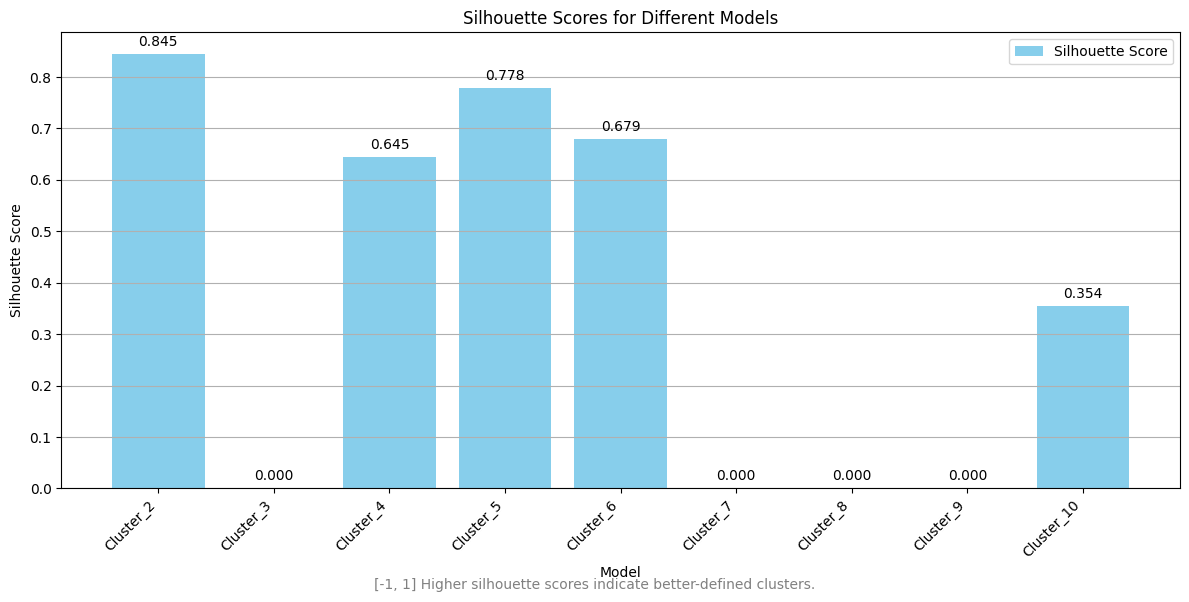

c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


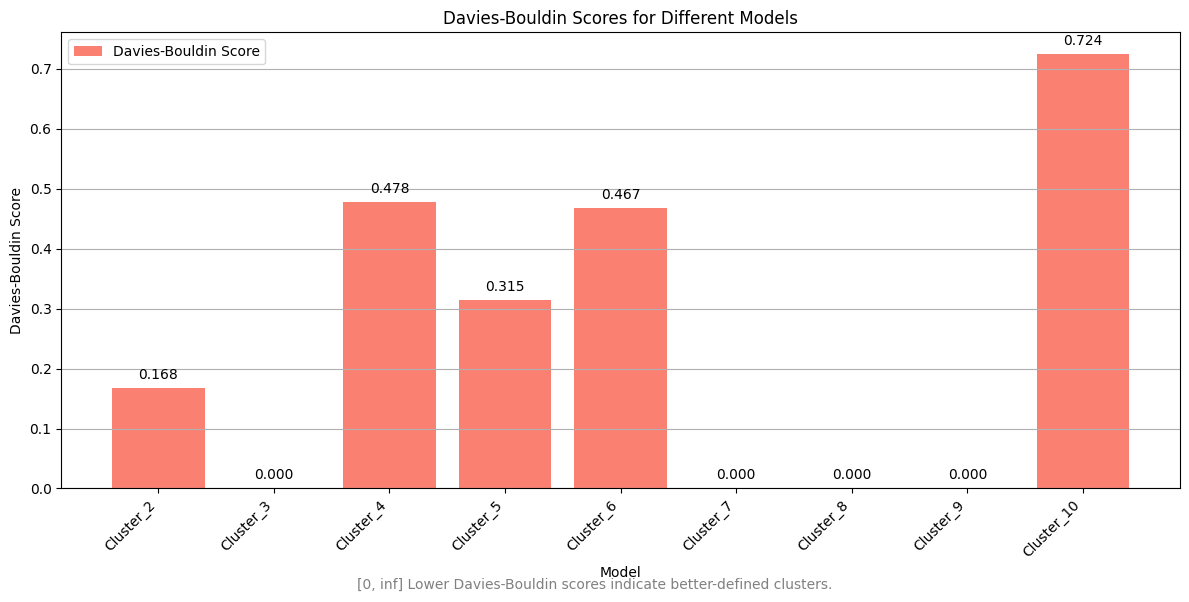

c:\Users\oddar\OneDrive - NTNU\Documents\Universitet\Masteroppgåve\Master-Thesis-Autoencoder-and-UMAP-clustering-on-functional-connectivity\Evaluate_models.py:242: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_names, rotation=45, ha='right')


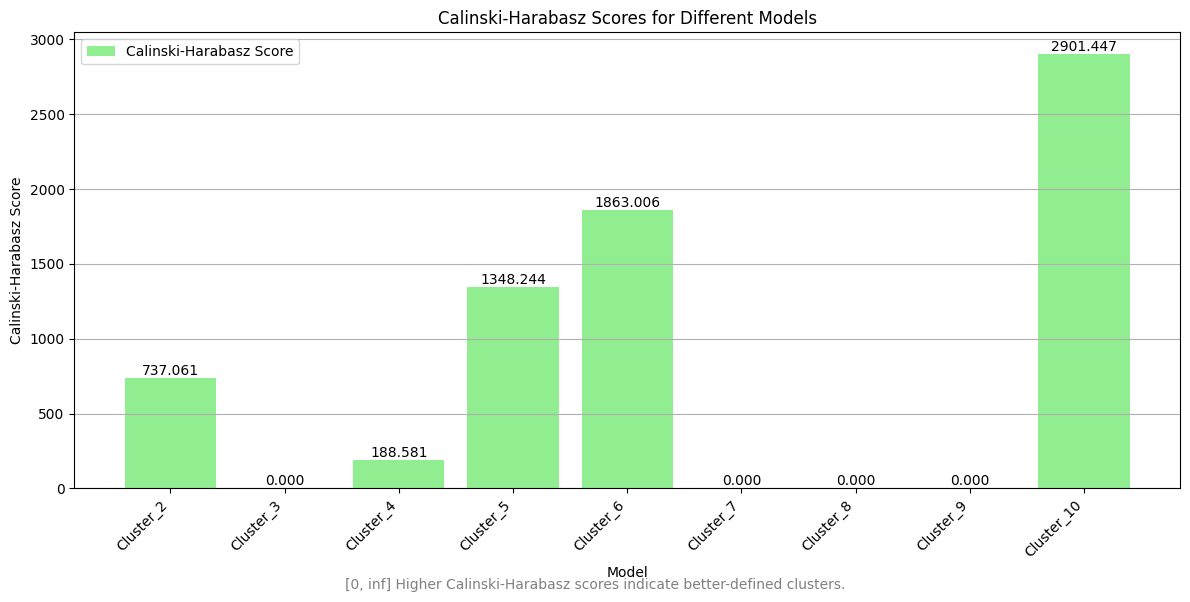


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_10.pt


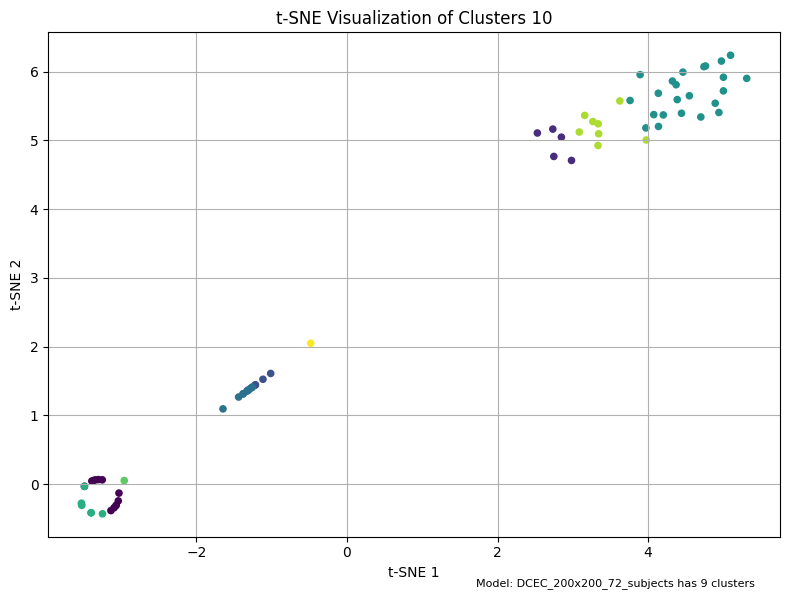


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_2.pt


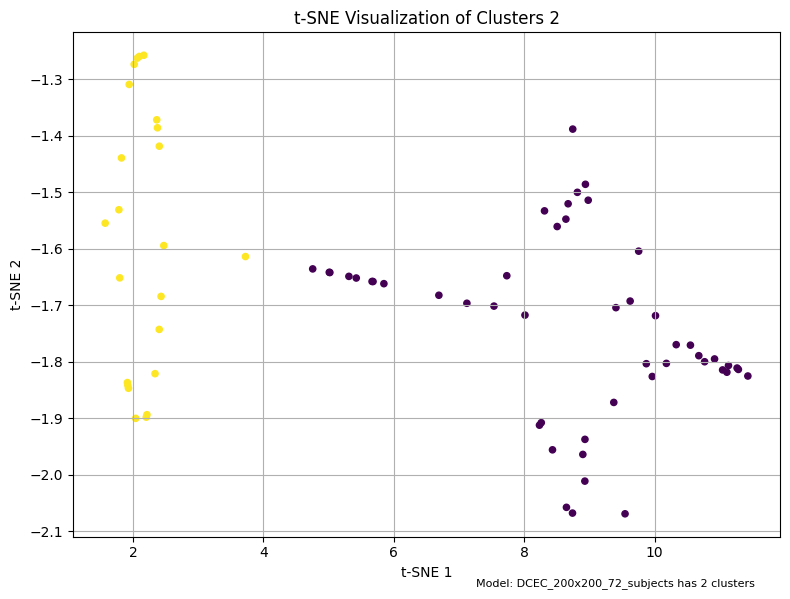


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_3.pt


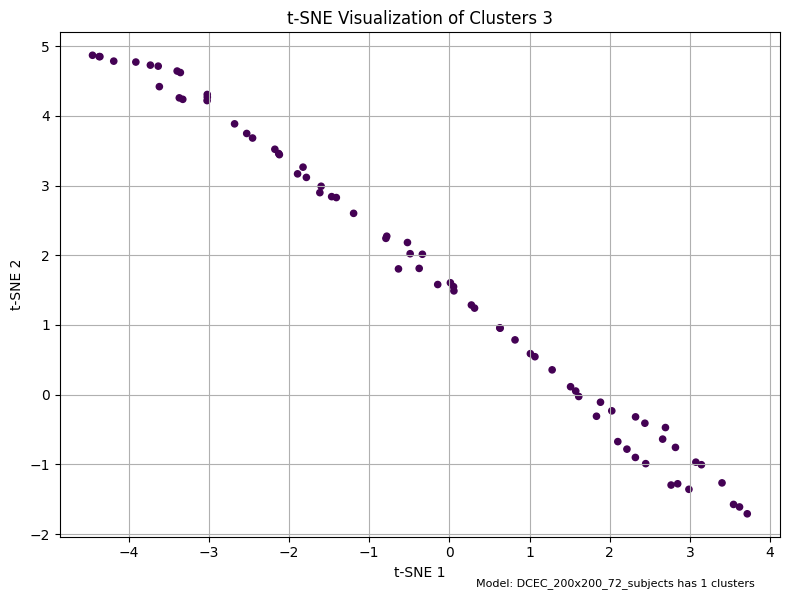


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_4.pt


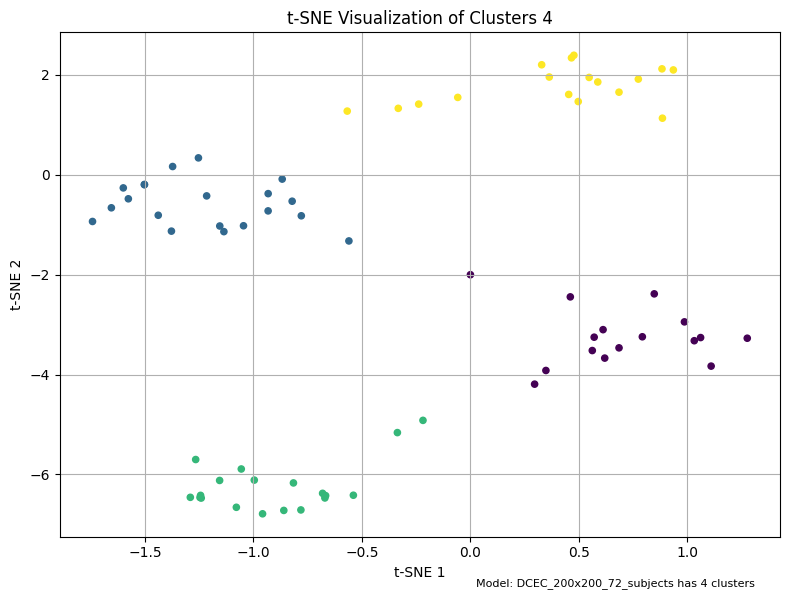


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_5.pt


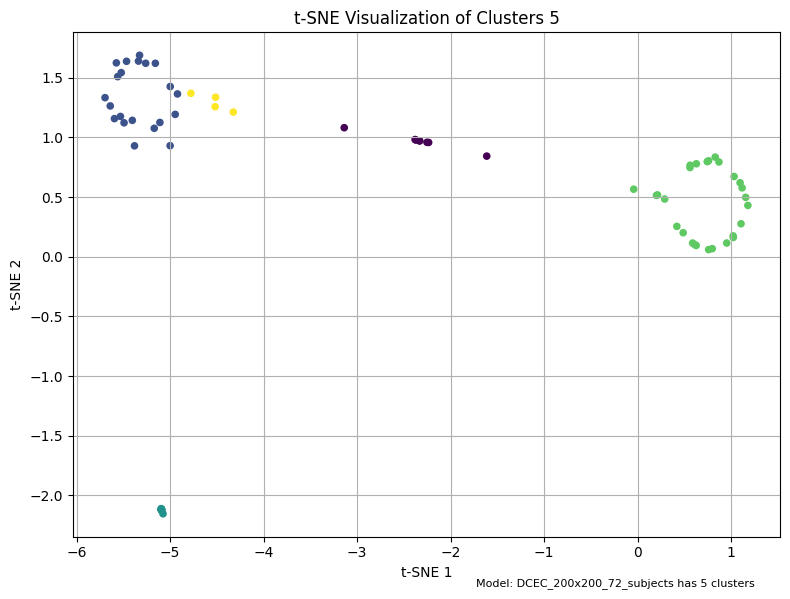


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_6.pt


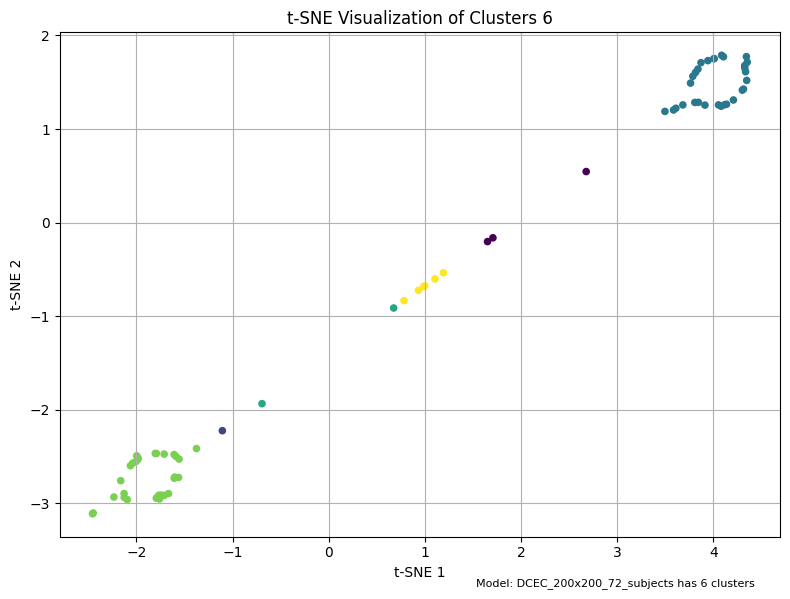


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_7.pt


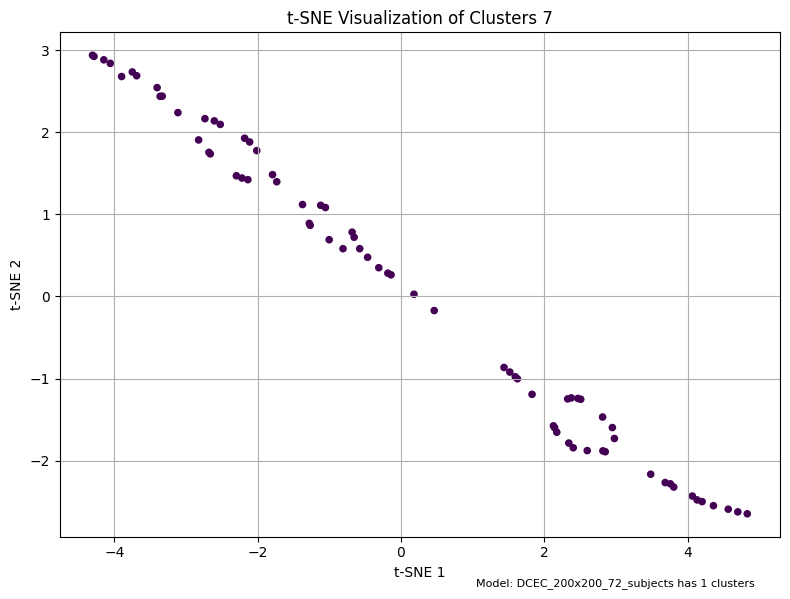


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_8.pt


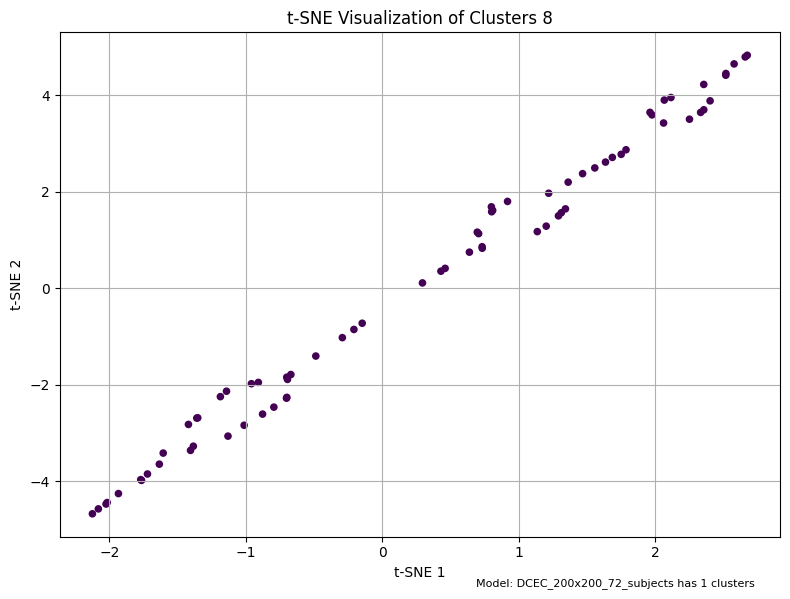


 Evaluating model: model_DCEC_200x200_72_subjects_Cluster_9.pt


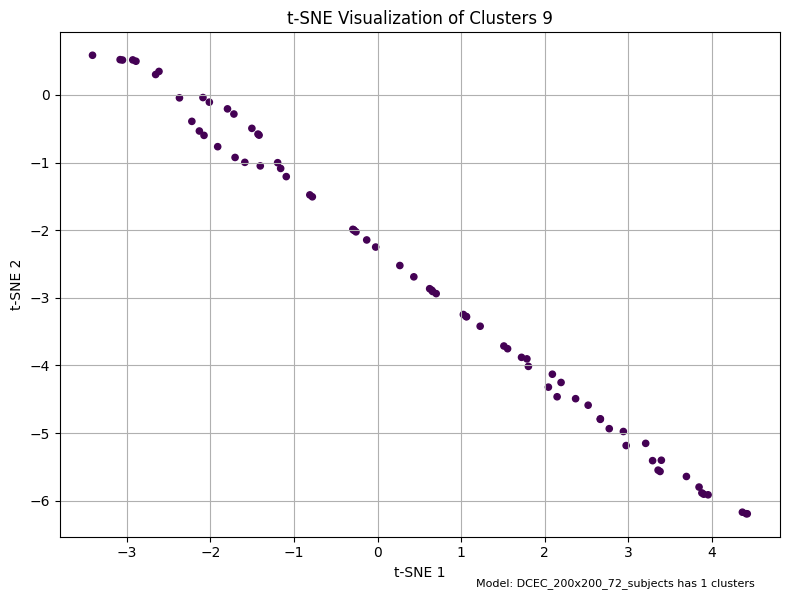

In [4]:
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from Convolutional_AE import plot_clustering, DCEC
from torch.utils.data import TensorDataset, DataLoader
import os
import torch

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_200x200_72_", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results, sort_scores=True)

# Plot the clustering results for the models
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
for model in os.listdir("Models"):
    if model.startswith("model_DCEC_200x200_72_"):
        print(f"\n Evaluating model: {model}")
        cluster_number = model.split("Cluster_")[1].split(".pt")[0]  # Extract the cluster number from the model name
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        cfg.n_clusters = int(cluster_number)  # Set the number of clusters to the extracted number
        temp_model = DCEC(cfg=cfg).to(device)   
        temp_model.load_state_dict(torch.load(f"Models/{model}"))
        
        plot_clustering(temp_model, dataloader, device)


In [ ]:
# TODO: Add code to visualise the clustering results using t-SNE
# Load the latest model
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.n_clusters = 3  # Set the number of clusters to 3 for the latest model
model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models/model_DCEC_200x200_clusters_3.pt"))  #


# Code for visualising the clustering results 
from Convolutional_AE import plot_training_history, plot_clustering, plot_reconstruction

plot_reconstruction(model, dataloader, device)
# plot_training_history(model)
plot_clustering(model, dataloader, device)

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_200x200_cluster", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results)




### UMAP

In [ ]:
from UMAP import UMAP

### HDBSCAN
Perform HDBSCAN on the data

In [ ]:
from My_HDBSCAN import hdbscan_clustering

hdbscan_clustering(Functional_connectivity_matrix=Functional_connectivity_matrix, save_labels=True)

### Evaluate the clusters
Evaluate the clusters using simple methods: Silhouette coefficient, Davies-Bouldin score and Calinski-Harabasz score

In [ ]:
from Evaluate_models import evaluate_clustering, evaluate_single_clustering
import os

# Define where to find the labels 
labels_path = "Clusters\DMACN__Clusters_3__label_0_21_label_1_19_label_2_32.txt"
evaluate_single_clustering(functional_connectivity_matrix=X, labels_path=labels_path)